In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)

import SPM_eqs
importlib.reload(SPM_eqs)

from IPython.display import display, Math
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

## The goal here 

$\dot{c}_p = f(I,\dot{I},c_n,\dot{c}_n, \widetilde{D})$ and $\dot{c}_n = f(I,\dot{I},c_p,\dot{c}_p,\widetilde{D})$ and 

In [121]:
def load_data(path):
    data = np.load(path)
    return data['I'], data['dI'], data['V'], data['cn'], data['cn_dot'], data['cp'], data['cp_dot'], data['valid']

# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('Euler_data/data_GRF_SPM.npz')
I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('t=5e3_GRF_data_c_dot.npz')


print(I.shape)

(250, 5000, 1)


In [122]:
sol,model_,param = sim_PyBaMM.simulate_DC1(0.5, T=1000, T_horizon=3600)   # simulate with t_eval = np.linspace(0, t_horizon, T)
Dn = sol.observe(model_.variables["X-averaged negative particle effective diffusivity [m2.s-1]"])([0,3600])[-1, 0]
Dp = sol.observe(model_.variables["X-averaged positive particle effective diffusivity [m2.s-1]"])([0,3600])[-1, 0]
cn_norm = cn / param['Maximum concentration in negative electrode [mol.m-3]']
cp_norm = cp / param['Maximum concentration in positive electrode [mol.m-3]']

In [123]:
def condition(cp = cp,cn = cn,I = I, cn_dot = cn_dot, cp_dot = cp_dot,param = param):
    Dp = sol.observe(model_.variables["X-averaged positive particle effective diffusivity [m2.s-1]"])([0,3600])[-1, 0]
    Dn = sol.observe(model_.variables["X-averaged negative particle effective diffusivity [m2.s-1]"])([0,3600])[-1, 0]
    cnmax = param['Maximum concentration in negative electrode [mol.m-3]']
    cpmax = param['Maximum concentration in positive electrode [mol.m-3]']
    Lp = param['Positive electrode thickness [m]']
    Ln = param['Negative electrode thickness [m]']

    return  cp_dot  * Lp**2/(Dp *cp) + cn_dot * Ln**2/ (cn*Dn)

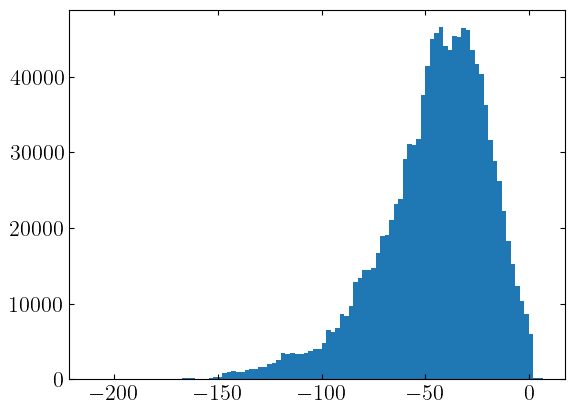

-210.9634973349773 6.465738683874253


In [124]:
plt.hist(condition().flatten(), bins=100)
plt.show()

print(np.min(condition()), np.max(condition()))


In [ ]:
a = np.linspace(-1,1,1000).reshape(-1,1); a0 = np.linspace(0,1,1000); b = np.linspace(-1,1,1000); b0 = np.linspace(0,1,1000) 


